# Intra-Patient vs Inter-Patient Evaluation

This notebook evaluates all trained models on both **inter-patient** and **intra-patient** test splits,
then produces side-by-side bar plots to compare generalisation performance.

| Split | Description |
|-------|-------------|
| **Inter-patient** | Test subjects that were *never seen* during training (different patients). Measures how well the model generalises to entirely new individuals. |
| **Intra-patient** | Second temporal half of the *training* subjects. Measures how well the model captures temporal dynamics of known individuals. |

A model that scores well on both splits demonstrates strong generalisation across patients *and* time.

In [1]:
import os
import sys
from pathlib import Path

# Ensure project root is on path
notebook_dir = Path().absolute()
if notebook_dir.name == "examples":
    os.chdir(notebook_dir.parent)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science", "no-latex"])
%matplotlib inline

## 1. Configuration

Choose the dataset and whether to recompute metrics from checkpoints or load precomputed metrics from `results/`.

In [2]:
# -- Configuration ------------------------------------------------------------
DATASET_ORDER = ["ts_young", "lsd"]
DATASET_CONFIGS = {
    "ts_young": {
        "label": "TS Young",
        "data_path": "data/ts_young/ts_young_TR0.72.mat",
        "lsd_data_dir": "data/lsd",
    },
    "lsd": {
        "label": "LSD",
        "data_path": "data/ts_young/ts_young_TR0.72.mat",
        "lsd_data_dir": "data/lsd",
    },
}
CHECKPOINT_DIR = "checkpoints"
RESULTS_DIR = "results"
USE_PRECOMPUTED_RESULTS = True
RESULT_FILES_BY_DATASET = {
    "ts_young": None,  # e.g. ["results/ts_young_hopf.json"]
    "lsd": None,       # e.g. ["results/lsd_hopf.json"]
}
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DISPLAY_METRICS = [
    "fc_correlation",
    "fc_mse",
    "fcd_ks",
    "phfcd_ks",
    "metastability_diff",
    "power_spectrum_distance",
    "temporal_correlation",
    "autocorr_distance",
    "phase_fc_correlation",
]

METRIC_LABELS = {
    "fc_correlation": "FC Correlation ↑",
    "fc_mse": "FC MSE ↓",
    "fcd_ks": "FCD (KS) ↓",
    "phfcd_ks": "Phase-FCD (KS) ↓",
    "metastability_diff": "Metastability Diff ↓",
    "power_spectrum_distance": "Power Spectrum Dist ↓",
    "temporal_correlation": "Temporal Correlation ↑",
    "autocorr_distance": "Autocorr Distance ↓",
    "phase_fc_correlation": "Phase FC Correlation ↑",
}

HIGHER_IS_BETTER = {"fc_correlation", "temporal_correlation", "phase_fc_correlation"}
DATASET_LABELS = {key: cfg["label"] for key, cfg in DATASET_CONFIGS.items()}

print(f"Device: {DEVICE}")
print(f"Datasets: {[DATASET_LABELS[d] for d in DATASET_ORDER]}")
print(
    "Using precomputed results from results/"
    if USE_PRECOMPUTED_RESULTS
    else "Recomputing metrics from checkpoints"
)


Device: cpu
Datasets: ['TS Young', 'LSD']
Using precomputed results from results/


## 2. Load Dataset & Create Data Loaders

We only need the dataset and loaders when recomputing metrics. If `USE_PRECOMPUTED_RESULTS = True`, this step is skipped.

In [3]:
from src.dataset import load_dataset, create_data_loaders
from src.training import HopfConfig

dataset_contexts = {}

for dataset_type in DATASET_ORDER:
    cfg = HopfConfig()
    cfg.dataset_type = dataset_type
    cfg.data_path = DATASET_CONFIGS[dataset_type]["data_path"]
    cfg.lsd_data_dir = DATASET_CONFIGS[dataset_type]["lsd_data_dir"]
    cfg.use_wandb = False
    cfg.dt_min = 0.05

    context = {
        "cfg": cfg,
        "dataset": None,
        "window_size": None,
        "test_inter_loader": None,
        "test_intra_loader": None,
    }

    if USE_PRECOMPUTED_RESULTS:
        print(f"[{DATASET_LABELS[dataset_type]}] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True")
    else:
        dataset = load_dataset(cfg, DEVICE)
        window_size = min(100, dataset.n_timepoints // 2)
        _, _, test_inter_loader, test_intra_loader = create_data_loaders(
            dataset=dataset,
            window_size=window_size,
            batch_size=cfg.batch_size,
            n_windows_per_epoch=cfg.n_windows_per_epoch,
            train_ratio=cfg.train_ratio,
            val_ratio=cfg.val_ratio,
            seed=cfg.seed,
            device=DEVICE,
        )
        context.update(
            dataset=dataset,
            window_size=window_size,
            test_inter_loader=test_inter_loader,
            test_intra_loader=test_intra_loader,
        )
        print(f"[{DATASET_LABELS[dataset_type]}] n_rois       : {dataset.n_rois}")
        print(f"[{DATASET_LABELS[dataset_type]}] n_subjects   : {dataset.timeseries.shape[0]}")
        print(f"[{DATASET_LABELS[dataset_type]}] n_timepoints : {dataset.n_timepoints}")
        print(f"[{DATASET_LABELS[dataset_type]}] window_size  : {window_size}")
        print(f"[{DATASET_LABELS[dataset_type]}] test_inter batches : {len(test_inter_loader)}")
        print(f"[{DATASET_LABELS[dataset_type]}] test_intra batches : {len(test_intra_loader)}")

    dataset_contexts[dataset_type] = context


[TS Young] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True
[LSD] Skipping dataset/loading step because USE_PRECOMPUTED_RESULTS=True


## 3. Discover Inputs

Either auto-discover checkpoints for recomputation or collect matching precomputed JSON files from `results/`.

In [4]:
import json

from src.models import load_model_from_checkpoint

_MODEL_TAGS = [
    ("gnn_hopf", "GNN Hopf"),
    ("hybrid_neural", "Hybrid+Neural"),
    ("hybrid_hopf", "Hybrid Hopf"),
    ("nsde", "Neural SDE"),
    ("hopf", "Hopf"),
]

def _short_label(stem: str) -> str:
    lower = stem.lower()
    for tag, label in _MODEL_TAGS:
        if tag in lower:
            return label + (" (Grid)" if "grid" in lower else "")
    return stem

results_by_dataset = {}

for dataset_type in DATASET_ORDER:
    context = dataset_contexts[dataset_type]
    models = {}
    result_paths = []

    if USE_PRECOMPUTED_RESULTS:
        configured_paths = RESULT_FILES_BY_DATASET.get(dataset_type)
        if configured_paths is not None:
            result_paths = [Path(p) for p in configured_paths]
        else:
            result_paths = sorted(Path(RESULTS_DIR).glob(f"{dataset_type}_*.json"))
            result_paths = [
                p for p in result_paths
                if p.stem != f"{dataset_type}_intra_vs_inter_results"
            ]

        print(f"[{DATASET_LABELS[dataset_type]}] Found {len(result_paths)} precomputed result files:")
        for p in result_paths:
            print(f"  {p}")
    else:
        ckpt_dir = Path(CHECKPOINT_DIR)
        checkpoint_paths = sorted(ckpt_dir.glob(f"*{dataset_type}*.pt"))
        print(f"[{DATASET_LABELS[dataset_type]}] Found {len(checkpoint_paths)} checkpoints:")
        for p in checkpoint_paths:
            print(f"  {p}")

        dataset = context["dataset"]
        for ckpt_path in checkpoint_paths:
            try:
                model, mtype, _ = load_model_from_checkpoint(str(ckpt_path), device=DEVICE)
                if model.n_rois != dataset.n_rois:
                    print(f"  Skipping {ckpt_path.name}: ROI mismatch ({model.n_rois} != {dataset.n_rois})")
                    continue
                label = _short_label(ckpt_path.stem)
                models[label] = model
                print(f"  Loaded '{label}' ({mtype})")
            except Exception as exc:
                print(f"  Failed to load {ckpt_path.name}: {exc}")

    results_by_dataset[dataset_type] = {
        "models": models,
        "result_paths": result_paths,
    }


[TS Young] Found 6 precomputed result files:
  results/ts_young_gnn_hopf.json
  results/ts_young_hopf.json
  results/ts_young_hopf_grid.json
  results/ts_young_hybrid_hopf.json
  results/ts_young_hybrid_neural.json
  results/ts_young_nsde.json
[LSD] Found 11 precomputed result files:
  results/lsd_control_metrics.json
  results/lsd_drop_input_metrics.json
  results/lsd_gnn_hopf.json
  results/lsd_hopf.json
  results/lsd_hopf_grid.json
  results/lsd_hybrid_hopf.json
  results/lsd_hybrid_neural.json
  results/lsd_in_silico_control.json
  results/lsd_in_silico_control_smoketest.json
  results/lsd_in_silico_control_smoketest_v2.json
  results/lsd_nsde.json


## 4. Evaluate Models on Both Test Splits

For each model we run `evaluate_model_loader_metrics` on both the inter-patient and intra-patient loaders, collecting the mean and standard deviation of every metric across batches.

In [5]:
from src.utils.evaluation import evaluate_model_loader_metrics, format_metrics_mean_std

for dataset_type in DATASET_ORDER:
    context = dataset_contexts[dataset_type]
    dataset_results = results_by_dataset[dataset_type]

    inter_results = {}
    intra_results = {}

    if USE_PRECOMPUTED_RESULTS:
        for result_path in dataset_results["result_paths"]:
            with open(result_path, "r") as f:
                payload = json.load(f)

            if payload.get("dataset_type") != dataset_type:
                print(f"[{DATASET_LABELS[dataset_type]}] Skipping {result_path.name}: dataset mismatch ({payload.get('dataset_type')})")
                continue

            metrics = payload.get("metrics", {})
            if "test_inter" not in metrics or "test_intra" not in metrics:
                print(f"[{DATASET_LABELS[dataset_type]}] Skipping {result_path.name}: missing test_inter/test_intra metrics")
                continue

            name = _short_label(payload.get("model", result_path.stem))
            inter_results[name] = {k: float(v) for k, v in metrics["test_inter"].items()}
            intra_results[name] = {k: float(v) for k, v in metrics["test_intra"].items()}

        dataset_results["models"] = {name: None for name in inter_results}
        print(f"[{DATASET_LABELS[dataset_type]}] Loaded precomputed metrics for {len(inter_results)} model(s): {list(inter_results.keys())}")
    else:
        cfg = context["cfg"]
        for name, model in dataset_results["models"].items():
            print(f"[{DATASET_LABELS[dataset_type]}] Evaluating {name} ...")
            inter_results[name] = evaluate_model_loader_metrics(
                model, context["test_inter_loader"], cfg, n_steps=context["window_size"], return_std=True,
            )
            intra_results[name] = evaluate_model_loader_metrics(
                model, context["test_intra_loader"], cfg, n_steps=context["window_size"], return_std=True,
            )
            print(f"  Inter: {format_metrics_mean_std(inter_results[name])}")
            print(f"  Intra: {format_metrics_mean_std(intra_results[name])}")
            print()

    dataset_results["inter_results"] = inter_results
    dataset_results["intra_results"] = intra_results
    dataset_results["model_names"] = list(inter_results.keys())

print("Metrics ready for all datasets.")


[TS Young] Loaded precomputed metrics for 6 model(s): ['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']
[LSD] Skipping lsd_control_metrics.json: dataset mismatch (None)
[LSD] Skipping lsd_drop_input_metrics.json: dataset mismatch (None)
[LSD] Skipping lsd_in_silico_control.json: missing test_inter/test_intra metrics
[LSD] Skipping lsd_in_silico_control_smoketest.json: missing test_inter/test_intra metrics
[LSD] Skipping lsd_in_silico_control_smoketest_v2.json: missing test_inter/test_intra metrics
[LSD] Loaded precomputed metrics for 6 model(s): ['GNN Hopf', 'Hopf', 'Hopf (Grid)', 'Hybrid Hopf', 'Hybrid+Neural', 'Neural SDE']
Metrics ready for all datasets.


## 5. Summary Table

Quick numerical overview before plotting.

In [6]:
import pandas as pd

rows = []
for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    for name in dataset_results["model_names"]:
        for split_name, results in [("Inter", dataset_results["inter_results"]), ("Intra", dataset_results["intra_results"])]:
            row = {"Dataset": DATASET_LABELS[dataset_type], "Model": name, "Split": split_name}
            for m in DISPLAY_METRICS:
                val = results[name].get(m, float("nan"))
                std = results[name].get(f"{m}_std", float("nan"))
                row[METRIC_LABELS.get(m, m)] = f"{val:.4f} +/- {std:.4f}"
            rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.set_index(["Dataset", "Model", "Split"], inplace=True)
df_summary


FC Correlation ↑           FC MSE ↓  \
Dataset  Model         Split                                         
TS Young GNN Hopf      Inter  0.9262 +/- 0.0088  0.0294 +/- 0.0057   
                       Intra  0.9367 +/- 0.0002  0.0286 +/- 0.0013   
         Hopf          Inter  0.9114 +/- 0.0009  0.0181 +/- 0.0004   
                       Intra  0.8992 +/- 0.0056  0.0151 +/- 0.0000   
         Hopf (Grid)   Inter  0.9191 +/- 0.0096  0.0933 +/- 0.0086   
                       Intra  0.9104 +/- 0.0099  0.0778 +/- 0.0034   
         Hybrid Hopf   Inter  0.9158 +/- 0.0051  0.0233 +/- 0.0014   
                       Intra  0.9326 +/- 0.0044  0.0248 +/- 0.0023   
         Hybrid+Neural Inter  0.8393 +/- 0.0145  0.0214 +/- 0.0026   
                       Intra  0.8742 +/- 0.0036  0.0177 +/- 0.0003   
         Neural SDE    Inter  0.9150 +/- 0.0045  0.0201 +/- 0.0048   
                       Intra  0.9346 +/- 0.0072  0.0333 +/- 0.0063   
LSD      GNN Hopf      Inter  0.9501 +/- 0.0146  0.0027 +/- 0.0008   
                       Intra  0.9872 +/- 0.0040  0.0034 +/- 0.0010   
         Hopf          Inter  0.9360 +/- 0.0167  0.0268 +/- 0.0013   
                       Intra  0.9619 +/- 0.0281  0.0386 +/- 0.0004   
         Hopf (Grid)   Inter  0.9137 +/- 0.0205  0.0160 +/- 0.0029   
                       Intra  0.9726 +/- 0.0074  0.0089 +/- 0.0013   
         Hybrid Hopf   Inter  0.9603 +/- 0.0291  0.0035 +/- 0.0011   
                       Intra  0.9906 +/- 0.0034  0.0082 +/- 0.0024   
         Hybrid+Neural Inter  0.9582 +/- 0.0049  0.0219 +/- 0.0028   
                       Intra  0.9791 +/- 0.0052  0.0163 +/- 0.0029   
         Neural SDE    Inter  0.9734 +/- 0.0205  0.0163 +/- 0.0045   
                       Intra  0.9750 +/- 0.0076  0.0056 +/- 0.0012   

                                     FCD (KS) ↓   Phase-FCD (KS) ↓  \
Dataset  Model         Split                                         
TS Young GNN Hopf      Inter  0.1330 +/- 0.0025  0.1262 +/- 0.0174   
                       Intra  0.1344 +/- 0.0026  0.1546 +/- 0.0069   
         Hopf          Inter  0.2354 +/- 0.0060  0.2538 +/- 0.0116   
                       Intra  0.2380 +/- 0.0006  0.2316 +/- 0.0046   
         Hopf (Grid)   Inter  0.2416 +/- 0.0023  0.0816 +/- 0.0023   
                       Intra  0.2467 +/- 0.0169  0.0581 +/- 0.0038   
         Hybrid Hopf   Inter  0.0816 +/- 0.0009  0.0523 +/- 0.0075   
                       Intra  0.0859 +/- 0.0027  0.0438 +/- 0.0074   
         Hybrid+Neural Inter  0.2233 +/- 0.0027  0.1950 +/- 0.0058   
                       Intra  0.2035 +/- 0.0066  0.1709 +/- 0.0156   
         Neural SDE    Inter  0.0489 +/- 0.0063  0.3047 +/- 0.0007   
                       Intra  0.0558 +/- 0.0026  0.3177 +/- 0.0067   
LSD      GNN Hopf      Inter  0.0596 +/- 0.0071  0.1153 +/- 0.0018   
                       Intra  0.0401 +/- 0.0047  0.1212 +/- 0.0032   
         Hopf          Inter  0.0955 +/- 0.0258  0.0536 +/- 0.0017   
                       Intra  0.1025 +/- 0.0120  0.0839 +/- 0.0125   
         Hopf (Grid)   Inter  0.1007 +/- 0.0094  0.0489 +/- 0.0098   
                       Intra  0.1008 +/- 0.0177  0.0325 +/- 0.0012   
         Hybrid Hopf   Inter  0.0661 +/- 0.0031  0.0902 +/- 0.0026   
                       Intra  0.0523 +/- 0.0062  0.0903 +/- 0.0044   
         Hybrid+Neural Inter  0.0709 +/- 0.0085  0.0222 +/- 0.0049   
                       Intra  0.0464 +/- 0.0317  0.0383 +/- 0.0095   
         Neural SDE    Inter  0.0417 +/- 0.0033  0.0700 +/- 0.0087   
                       Intra  0.0390 +/- 0.0045  0.0747 +/- 0.0040   

                             Metastability Diff ↓ Power Spectrum Dist ↓  \
Dataset  Model         Split                                              
TS Young GNN Hopf      Inter    0.0309 +/- 0.0002     0.0069 +/- 0.0001   
                       Intra    0.0282 +/- 0.0022     0.0069 +/- 0.0000   
         Hopf          Inter    0.0095 +/- 0.0027     0.0041 +/- 0.0001   
              

## 6. Grouped Bar Plots — Inter vs Intra per Metric

Each subplot shows one metric. For every model, two bars are drawn side-by-side:
the **blue** bar is the inter-patient score and the **orange** bar is the intra-patient score.
Error bars show the standard deviation across batches.

Metrics where **higher is better** (FC Correlation, Temporal Correlation, Phase FC Correlation)
are annotated with an upward arrow; all others are **lower is better**.

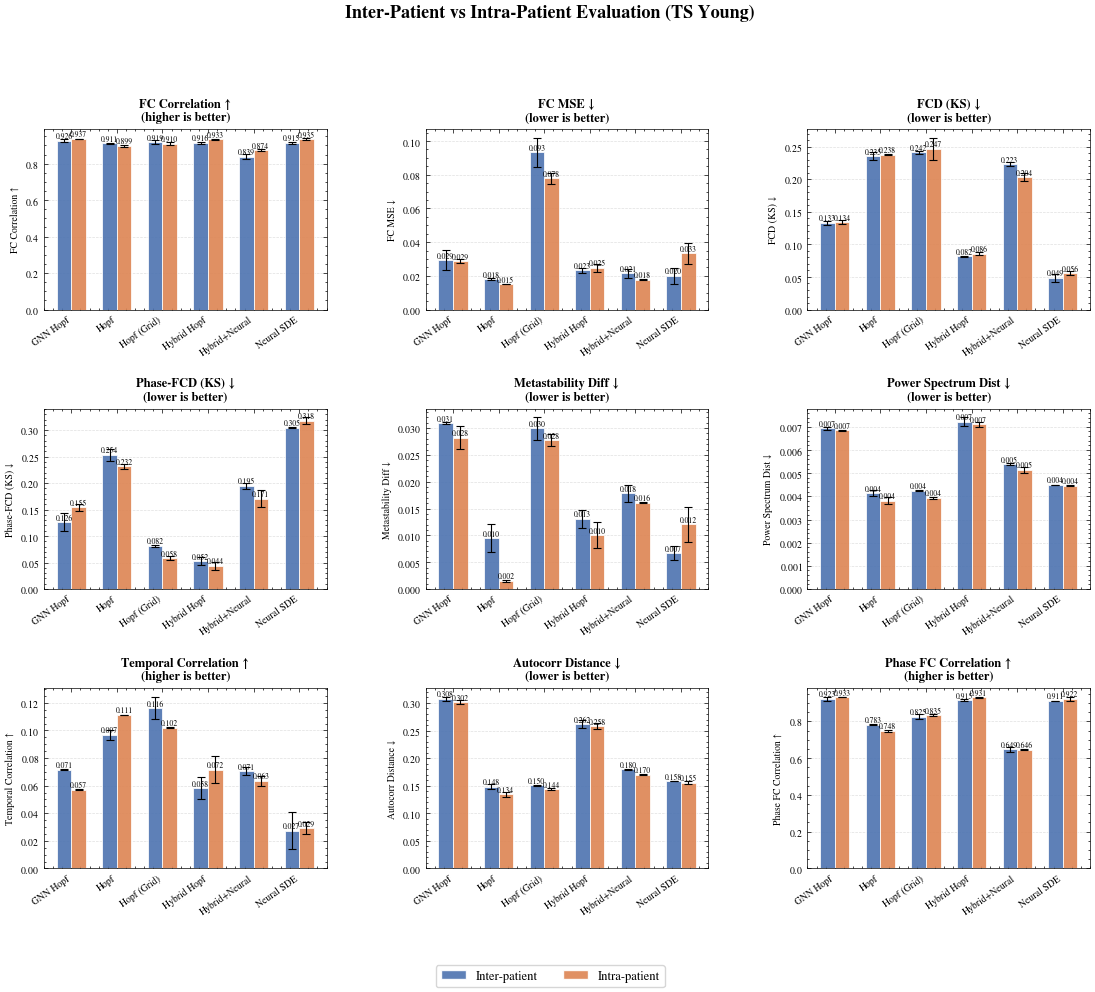

Saved bar plots to paper/images/ts_young


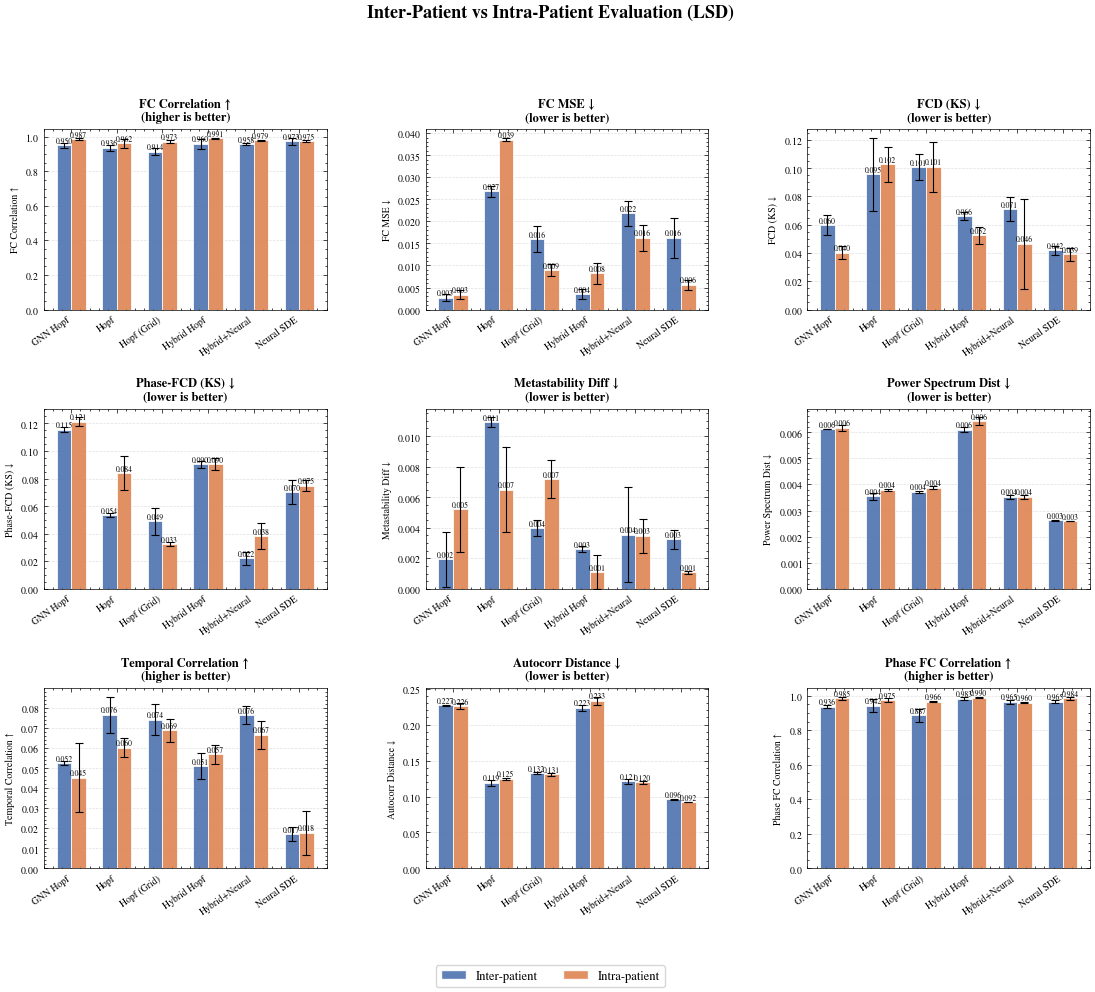

Saved bar plots to paper/images/lsd


In [7]:
from matplotlib.gridspec import GridSpec
%matplotlib inline

INTER_COLOR = "#4C72B0"
INTRA_COLOR = "#DD8452"

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]

    n_models = len(model_names)
    n_metrics = len(DISPLAY_METRICS)
    n_cols = 3
    n_rows = int(np.ceil(n_metrics / n_cols))
    bar_width = 0.32
    x = np.arange(n_models)

    fig = plt.figure(figsize=(4.5 * n_cols, 3.2 * n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.35)

    for idx, metric_key in enumerate(DISPLAY_METRICS):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])

        inter_means = [inter_results[m].get(metric_key, 0) for m in model_names]
        intra_means = [intra_results[m].get(metric_key, 0) for m in model_names]
        inter_stds = [inter_results[m].get(f"{metric_key}_std", 0) for m in model_names]
        intra_stds = [intra_results[m].get(f"{metric_key}_std", 0) for m in model_names]

        bars_inter = ax.bar(
            x - bar_width / 2, inter_means, bar_width,
            yerr=inter_stds, label="Inter-patient",
            color=INTER_COLOR, edgecolor="white", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
            zorder=3, alpha=0.9,
        )
        bars_intra = ax.bar(
            x + bar_width / 2, intra_means, bar_width,
            yerr=intra_stds, label="Intra-patient",
            color=INTRA_COLOR, edgecolor="white", linewidth=0.6,
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
            zorder=3, alpha=0.9,
        )

        direction = "higher is better" if metric_key in HIGHER_IS_BETTER else "lower is better"
        pretty_name = METRIC_LABELS.get(metric_key, metric_key)
        ax.set_title(f"{pretty_name}\n({direction})", fontsize=9, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_ylabel(pretty_name, fontsize=7)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.xaxis.grid(False)

        for bars in [bars_inter, bars_intra]:
            for bar in bars:
                h = bar.get_height()
                if not np.isnan(h) and h != 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2, h,
                        f"{h:.3f}", ha="center", va="bottom",
                        fontsize=5.5, fontweight="medium",
                    )

    for idx in range(n_metrics, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.add_subplot(gs[row, col]).set_visible(False)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=INTER_COLOR, edgecolor="white", alpha=0.9),
        plt.Rectangle((0, 0), 1, 1, facecolor=INTRA_COLOR, edgecolor="white", alpha=0.9),
    ]
    fig.legend(
        handles, ["Inter-patient", "Intra-patient"],
        loc="lower center", ncol=2, fontsize=9,
        frameon=True, fancybox=True, shadow=False,
        bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle(
        f"Inter-Patient vs Intra-Patient Evaluation ({DATASET_LABELS[dataset_type]})",
        fontsize=13, fontweight="bold", y=1.01,
    )

    out_dir = Path(f"paper/images/{dataset_type}")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / "intra_vs_inter_barplots.pdf", bbox_inches="tight", dpi=200)
    out_dir_png = Path(f"paper/images_png/{dataset_type}")
    out_dir_png.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir_png / "intra_vs_inter_barplots.png", bbox_inches="tight", dpi=200)
    out_dir_svg = Path(f"paper/images_svg/{dataset_type}")
    out_dir_svg.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir_svg / "intra_vs_inter_barplots.svg", bbox_inches="tight")
    plt.show()
    print(f"Saved bar plots to {out_dir}")


## 8. Delta Plot — Intra minus Inter Gap

How much does each model's performance change between the two splits?
Positive delta means the model is *better* on the intra-patient split; negative means it
generalises better to unseen patients. Bars are coloured by sign.

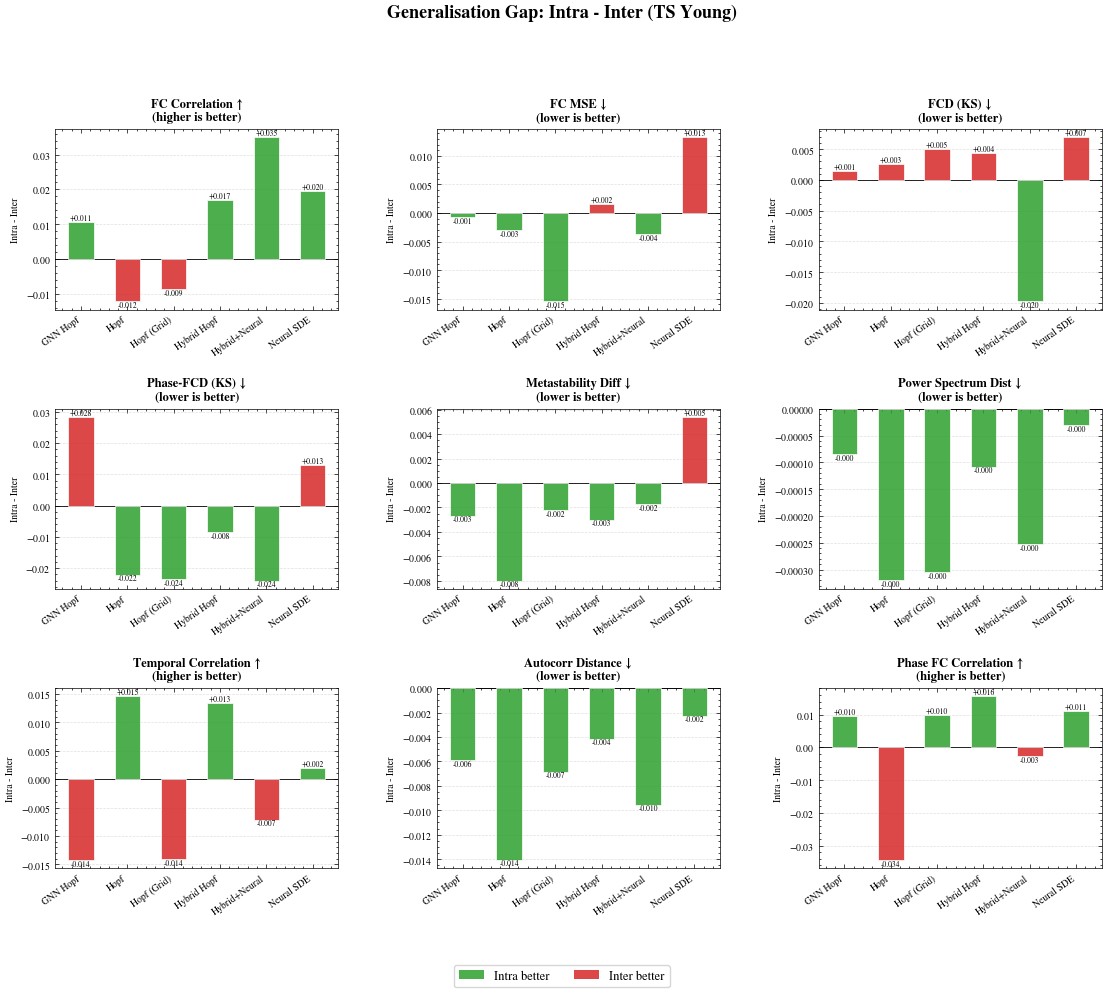

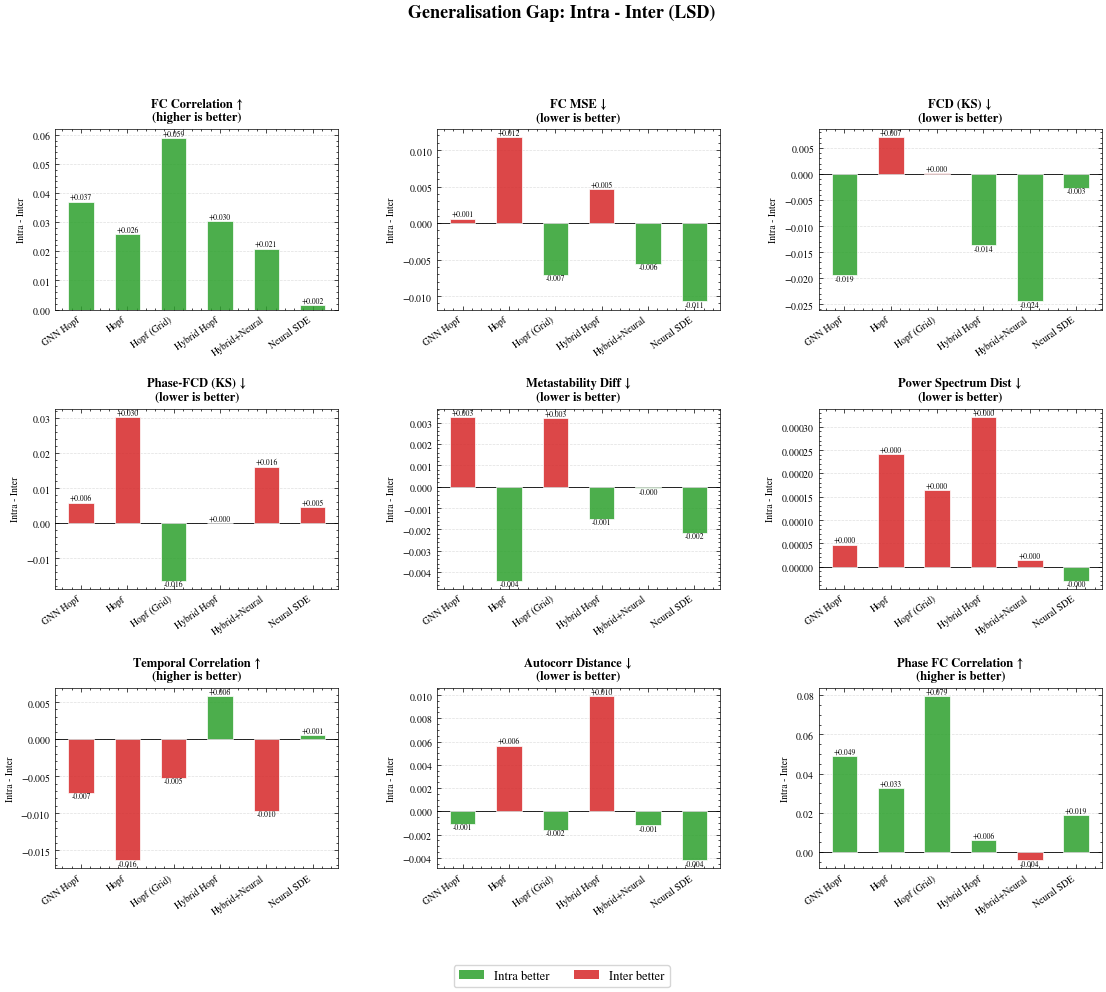

In [8]:
BETTER_COLOR = "#2ca02c"
WORSE_COLOR = "#d62728"

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]

    n_models = len(model_names)
    n_metrics = len(DISPLAY_METRICS)
    n_cols = 3
    n_rows = int(np.ceil(n_metrics / n_cols))
    x = np.arange(n_models)

    fig = plt.figure(figsize=(4.5 * n_cols, 3.2 * n_rows))
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.55, wspace=0.35)

    for idx, metric_key in enumerate(DISPLAY_METRICS):
        row, col = divmod(idx, n_cols)
        ax = fig.add_subplot(gs[row, col])

        inter_vals = np.array([inter_results[m].get(metric_key, 0) for m in model_names])
        intra_vals = np.array([intra_results[m].get(metric_key, 0) for m in model_names])
        delta = intra_vals - inter_vals

        if metric_key in HIGHER_IS_BETTER:
            colors = [BETTER_COLOR if d > 0 else WORSE_COLOR for d in delta]
        else:
            colors = [BETTER_COLOR if d < 0 else WORSE_COLOR for d in delta]

        ax.bar(x, delta, width=0.55, color=colors, edgecolor="white", linewidth=0.6, zorder=3, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.6, zorder=2)

        pretty_name = METRIC_LABELS.get(metric_key, metric_key)
        direction = "higher is better" if metric_key in HIGHER_IS_BETTER else "lower is better"
        ax.set_title(f"{pretty_name}\n({direction})", fontsize=9, fontweight="bold", pad=6)
        ax.set_xticks(x)
        ax.set_xticklabels(model_names, rotation=35, ha="right", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_ylabel("Intra - Inter", fontsize=7)
        ax.set_axisbelow(True)
        ax.yaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.xaxis.grid(False)

        for i, d in enumerate(delta):
            va = "bottom" if d >= 0 else "top"
            ax.text(i, d, f"{d:+.3f}", ha="center", va=va, fontsize=5.5, fontweight="medium")

    for idx in range(n_metrics, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        fig.add_subplot(gs[row, col]).set_visible(False)

    handles = [
        plt.Rectangle((0, 0), 1, 1, facecolor=BETTER_COLOR, alpha=0.85),
        plt.Rectangle((0, 0), 1, 1, facecolor=WORSE_COLOR, alpha=0.85),
    ]
    fig.legend(
        handles, ["Intra better", "Inter better"],
        loc="lower center", ncol=2, fontsize=9,
        frameon=True, fancybox=True, bbox_to_anchor=(0.5, -0.02),
    )
    fig.suptitle(
        f"Generalisation Gap: Intra - Inter ({DATASET_LABELS[dataset_type]})",
        fontsize=13, fontweight="bold", y=1.01,
    )

    out_dir = Path(f"paper/images/{dataset_type}")
    out_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir / "intra_vs_inter_delta.pdf", bbox_inches="tight", dpi=200)
    out_dir_png = Path(f"paper/images_png/{dataset_type}")
    out_dir_png.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir_png / "intra_vs_inter_delta.png", bbox_inches="tight", dpi=200)
    out_dir_svg = Path(f"paper/images_svg/{dataset_type}")
    out_dir_svg.mkdir(parents=True, exist_ok=True)
    plt.savefig(out_dir_svg / "intra_vs_inter_delta.svg", bbox_inches="tight")
    plt.show()


## 9. Horizontal Grouped Boxplot — Compact Single-Figure Summary

A condensed horizontal per-model boxplot summary for each metric. When only mean and standard deviation are available, the boxes are drawn from those summary statistics so the models remain visible.


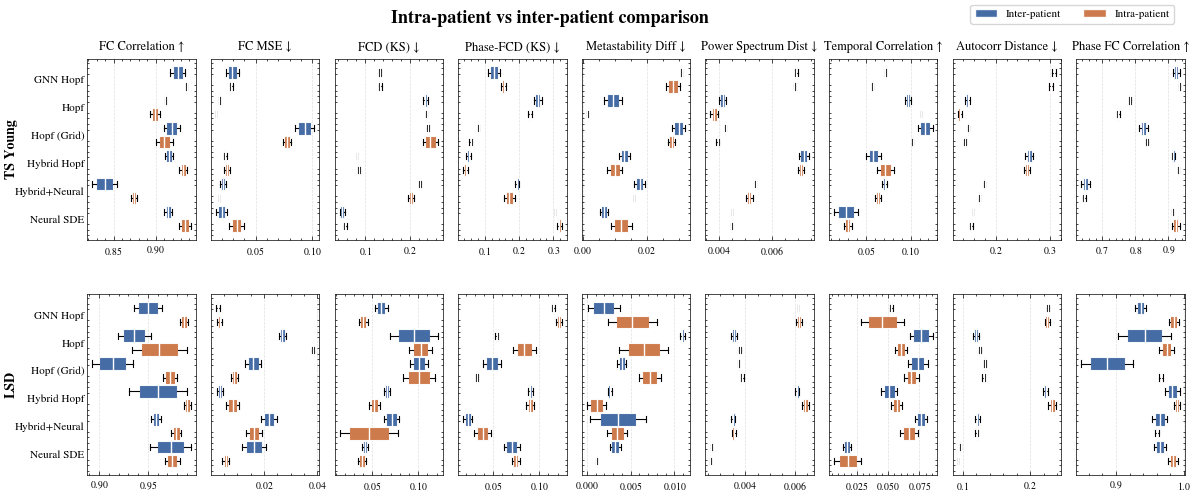

Saved combined comparison plot to paper/images/comparison


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

DATASET_ROW_COLORS = {
    "ts_young": {"inter": "#5B84C4", "intra": "#E59A6B"},
    "lsd": {"inter": "#355F9E", "intra": "#C96F3D"},
}

BOX_OFFSET = 0.25
BOX_WIDTH = 0.45

def _finite_array(values):
    arr = np.asarray(values, dtype=float)
    return arr[np.isfinite(arr)]

def _box_stats(metric_dict, metric_key, label):
    raw_values = metric_dict.get(f"{metric_key}_values")
    if isinstance(raw_values, (list, tuple, np.ndarray)):
        raw = _finite_array(raw_values)
        if raw.size:
            q1, med, q3 = np.percentile(raw, [25, 50, 75])
            return {
                "label": label,
                "whislo": float(raw.min()),
                "q1": float(q1),
                "med": float(med),
                "q3": float(q3),
                "whishi": float(raw.max()),
                "mean": float(raw.mean()),
                "fliers": [],
            }

    mean = metric_dict.get(metric_key, np.nan)
    std = metric_dict.get(f"{metric_key}_std", np.nan)
    if not np.isfinite(mean):
        return None

    std = float(std) if np.isfinite(std) else 0.0
    iqr_half = 0.67449 * std
    whisk_half = 1.5 * iqr_half
    return {
        "label": label,
        "whislo": float(mean - whisk_half),
        "q1": float(mean - iqr_half),
        "med": float(mean),
        "q3": float(mean + iqr_half),
        "whishi": float(mean + whisk_half),
        "mean": float(mean),
        "fliers": [],
    }

n_metrics = len(DISPLAY_METRICS)
max_models = max(len(results_by_dataset[dataset_type]["model_names"]) for dataset_type in DATASET_ORDER)
fig, axes = plt.subplots(
    len(DATASET_ORDER), n_metrics,
    figsize=(1.28 * n_metrics + 1.6, 0.45 * max_models * len(DATASET_ORDER) ),
    sharey="row",
)

if len(DATASET_ORDER) == 1:
    axes = np.array([axes])
if n_metrics == 1:
    axes = axes[:, np.newaxis]

legend_handles = None

for row, dataset_type in enumerate(DATASET_ORDER):
    dataset_results = results_by_dataset[dataset_type]
    model_names = dataset_results["model_names"]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]
    row_colors = DATASET_ROW_COLORS["lsd"]
    y = np.arange(len(model_names))

    for col, m_key in enumerate(DISPLAY_METRICS):
        ax = axes[row, col]

        inter_stats = []
        inter_pos = []
        intra_stats = []
        intra_pos = []

        for idx, name in enumerate(model_names):
            inter_box = _box_stats(inter_results[name], m_key, name)
            intra_box = _box_stats(intra_results[name], m_key, name)
            if inter_box is not None:
                inter_stats.append(inter_box)
                inter_pos.append(y[idx] - BOX_OFFSET)
            if intra_box is not None:
                intra_stats.append(intra_box)
                intra_pos.append(y[idx] + BOX_OFFSET)

        inter_bxp = ax.bxp(
            inter_stats,
            positions=inter_pos,
            widths=BOX_WIDTH,
            vert=False,
            patch_artist=True,
            showfliers=False,
            showmeans=False,
            #meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=3.2),
            medianprops=dict(color="white", linewidth=1.0),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            boxprops=dict(linewidth=0.8),
            zorder=3,
        )
        intra_bxp = ax.bxp(
            intra_stats,
            positions=intra_pos,
            widths=BOX_WIDTH,
            vert=False,
            patch_artist=True,
            showfliers=False,
            showmeans=False,
            #meanprops=dict(marker="o", markerfacecolor="white", markeredgecolor="black", markersize=3.2),
            medianprops=dict(color="white", linewidth=1.0),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            boxprops=dict(linewidth=0.8),
            zorder=3,
        )

        for patch in inter_bxp["boxes"]:
            patch.set_facecolor(row_colors["inter"])
            patch.set_edgecolor("white")
            patch.set_alpha(0.92)
        for patch in intra_bxp["boxes"]:
            patch.set_facecolor(row_colors["intra"])
            patch.set_edgecolor("white")
            patch.set_alpha(0.92)

        if legend_handles is None:
            legend_handles = [
                plt.Rectangle((0, 0), 1, 1, facecolor=row_colors["inter"], edgecolor="white", alpha=0.92),
                plt.Rectangle((0, 0), 1, 1, facecolor=row_colors["intra"], edgecolor="white", alpha=0.92),
            ]

        ax.set_yticks(y)
        if col == 0:
            ax.set_yticklabels(model_names, fontsize=8)
            ax.tick_params(axis="y", labelleft=True, length=0, pad=2)
            ax.text(
                -0.7, 0.5, DATASET_LABELS[dataset_type],
                transform=ax.transAxes, rotation=90,
                va="center", ha="center", fontsize=10, fontweight="bold",
            )
        else:
            ax.tick_params(axis="y", labelleft=False, length=0)

        ax.tick_params(axis="x", labelsize=7)
        ax.set_axisbelow(True)
        ax.xaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
        ax.yaxis.grid(False)
        ax.invert_yaxis()

        if row == 0:
            ax.set_title(METRIC_LABELS.get(m_key, m_key), fontsize=9)

fig.legend(
    legend_handles, ["Inter-patient", "Intra-patient"],
    loc="upper right", ncol=2, fontsize=8,
    frameon=True, bbox_to_anchor=(0.98, 0.94),
)
fig.suptitle(
    "Intra-patient vs inter-patient comparison",
    fontsize=13, fontweight="bold", y=0.92
)

comparison_dir = Path("paper/images/comparison")
comparison_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout(rect=(0.08, 0, 1, 0.95))
plt.subplots_adjust(wspace=0.14, hspace=0.3)
plt.savefig(comparison_dir / "intra_vs_inter_rotated_both_datasets2.pdf", bbox_inches="tight", dpi=200)
comparison_dir_png = Path("paper/images_png/comparison")
comparison_dir_png.mkdir(parents=True, exist_ok=True)
plt.savefig(comparison_dir_png / "intra_vs_inter_rotated_both_datasets2.png", bbox_inches="tight", dpi=200)
comparison_dir_svg = Path("paper/images_svg/comparison")
comparison_dir_svg.mkdir(parents=True, exist_ok=True)
plt.savefig(comparison_dir_svg / "intra_vs_inter_rotated_both_datasets2.svg", bbox_inches="tight")
# plt.savefig(comparison_dir / "intra_vs_inter_rotated_both_datasets.png", bbox_inches="tight", dpi=200)
plt.show()
print(f"Saved combined comparison plot to {comparison_dir}")


## 8. Save Results to JSON

Persist the per-dataset metrics so they can be reloaded without re-running evaluation.


In [10]:
import json

for dataset_type in DATASET_ORDER:
    dataset_results = results_by_dataset[dataset_type]
    output = {
        "dataset_type": dataset_type,
        "test_inter": {
            name: {k: float(v) for k, v in metrics.items()}
            for name, metrics in dataset_results["inter_results"].items()
        },
        "test_intra": {
            name: {k: float(v) for k, v in metrics.items()}
            for name, metrics in dataset_results["intra_results"].items()
        },
    }

    output_path = Path(f"results/{dataset_type}_intra_vs_inter_results.json")
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "w") as f:
        json.dump(output, f, indent=2, sort_keys=True)

    print(f"Results saved to {output_path}")


Results saved to results/ts_young_intra_vs_inter_results.json
Results saved to results/lsd_intra_vs_inter_results.json


## 10. FC-Only Comparison — Hopf vs Neural SDE vs Hybrid Hopf

Focused bar plot showing only **FC correlation** for the three core models on both
inter-patient and intra-patient splits. Colours match the per-dataset comparison figures
(Hopf = salmon, Neural SDE = blue, Hybrid Hopf = green).

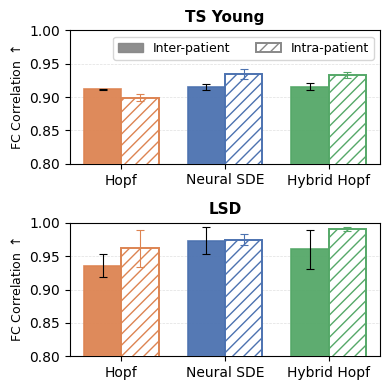

Saved FC-only comparison plot to paper/images/comparison


In [15]:
plt.style.use('default')
FC_MODELS = ["Hopf", "Neural SDE", "Hybrid Hopf"]
FC_MODEL_COLORS = {
    "Hopf": "#DD8452",        # salmon
    "Neural SDE": "#4C72B0",  # blue
    "Hybrid Hopf": "#55A868", # green
}
FC_DATASETS = ["ts_young", "lsd"]

fig, axes = plt.subplots(len(FC_DATASETS), 1, figsize=(4, 4), sharey=True)

x = np.arange(len(FC_MODELS))
bar_width = 0.36

for ax, dataset_type in zip(axes, FC_DATASETS):
    dataset_results = results_by_dataset[dataset_type]
    inter_results = dataset_results["inter_results"]
    intra_results = dataset_results["intra_results"]

    for i, model in enumerate(FC_MODELS):
        inter_mean = inter_results[model].get("fc_correlation", np.nan)
        intra_mean = intra_results[model].get("fc_correlation", np.nan)
        inter_std = inter_results[model].get("fc_correlation_std", 0.0)
        intra_std = intra_results[model].get("fc_correlation_std", 0.0)
        color = FC_MODEL_COLORS[model]

        ax.bar(
            x[i] - bar_width / 2, inter_mean, bar_width,
            yerr=inter_std,
            facecolor=color, edgecolor=color, linewidth=1.2,
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8),
            zorder=3, alpha=0.95,
        )
        ax.bar(
            x[i] + bar_width / 2, intra_mean, bar_width,
            yerr=intra_std,
            facecolor="white", edgecolor=color, linewidth=1.4,
            hatch="///",
            capsize=3, error_kw=dict(lw=0.8, capthick=0.8, ecolor=color),
            zorder=3,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(FC_MODELS, fontsize=10)
    ax.set_title(DATASET_LABELS[dataset_type], fontsize=11, fontweight="bold")
    ax.set_ylim(0.8, 1.0)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4, linewidth=0.5)
    ax.xaxis.grid(False)

axes[0].set_ylabel("FC Correlation $\\uparrow$", fontsize=9)
axes[1].set_ylabel("FC Correlation $\\uparrow$", fontsize=9)

# Split-style legend (neutral colour to indicate the pattern, not the model)
split_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#888888", edgecolor="#888888", alpha=0.95),
    plt.Rectangle((0, 0), 1, 1, facecolor="white", edgecolor="#888888", hatch="///", linewidth=1.4),
]
axes[0].legend(
    split_handles, ["Inter-patient", "Intra-patient"],
    loc="upper right", fontsize=9, frameon=True, fancybox=True, ncols=2,
)

plt.tight_layout()

out_dir = Path("paper/images/comparison")
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "fc_intra_vs_inter_three_models.pdf", bbox_inches="tight", dpi=200)
out_dir_png = Path("paper/images_png/comparison")
out_dir_png.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir_png / "fc_intra_vs_inter_three_models.png", bbox_inches="tight", dpi=200)
out_dir_svg = Path("paper/images_svg/comparison")
out_dir_svg.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir_svg / "fc_intra_vs_inter_three_models.svg", bbox_inches="tight")
plt.show()
print(f"Saved FC-only comparison plot to {out_dir}")